In [1]:
# Install some packages
!pip install rasterio
!pip install earthpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.6 MB/s eta 0:00:00


In [2]:
!pip install earthengine-api
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.0 MB/s eta 0:00:00


In [4]:
import ee
import geemap
# Trigger the authentication flow.
ee.Authenticate()
ee.Initialize(project='p3-gee')

EEException: Project p3-gee is not registered to use Earth Engine. Visit https://console.cloud.google.com/earth-engine/configuration?project=p3-gee to register your project. See https://developers.google.com/earth-engine/guides/access for more details. If you have previously registered your project for noncommercial use and lost access, you will need to re-verify your eligibility. See the https://developers.google.com/earth-engine/guides/access#configuring_noncommercial_access for more details.

In [5]:
# Load the JRC Global Surface Water dataset
gsw = ee.Image("JRC/GSW1_2/GlobalSurfaceWater")

EEException: Project p3-gee is not registered to use Earth Engine. Visit https://console.cloud.google.com/earth-engine/configuration?project=p3-gee to register your project. See https://developers.google.com/earth-engine/guides/access for more details. If you have previously registered your project for noncommercial use and lost access, you will need to re-verify your eligibility. See the https://developers.google.com/earth-engine/guides/access#configuring_noncommercial_access for more details.

In [ ]:
print(gsw)

ee.Image({
  "functionInvocationValue": {
    "functionName": "Image.load",
    "arguments": {
      "id": {
        "constantValue": "JRC/GSW1_2/GlobalSurfaceWater"
      }
    }
  }
})


In [ ]:
import ee
import rasterio

ee.Initialize()

# Assuming 'IMAGE_PATH' is the path to your raster file
with rasterio.open(IMAGE_PATH) as dataset:
    bounds = dataset.bounds
    extent = ee.Geometry.Rectangle([bounds.left, bounds.bottom, bounds.right, bounds.top])

# Now you can use 'extent' with Earth Engine

In [ ]:
gsw_clipped = gsw.clip(extent)

In [ ]:
import folium

# Function to add Earth Engine layers to folium map
def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Map Data &copy; <a href="https://earthengine.google.com/">Google Earth Engine</a>',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)

# Add Earth Engine layer adding method to folium
folium.Map.add_ee_layer = add_ee_layer

# Set visualization parameters for GSW
vis_params = {
    'palette': ["ffffff", "ffbbbb", "0000ff"],
    'min': 0.0,
    'max': 3.0,
    'bands': ['occurrence']
}

# Create a folium map object
my_map = folium.Map(location=[20, 0], zoom_start=3)

# Add the GSW layer to the map
my_map.add_ee_layer(gsw_clipped, vis_params, 'Global Surface Water')

# Add a layer control panel to the map
my_map.add_child(folium.LayerControl())

# Assuming 'extent' is your Earth Engine Geometry
centroid = extent.centroid().getInfo()['coordinates']
map_center = [centroid[1], centroid[0]]  # Reverse the coordinates for folium (latitude, longitude)

In [ ]:
# Display the map
my_map

In [ ]:
# Import packages
import pandas as pd
import numpy as np
import keras
from keras import Sequential
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten, Input, GlobalMaxPooling1D
from keras.callbacks import EarlyStopping
from keras import Model
import rasterio
import earthpy.plot as ep
from keras.utils import to_categorical, plot_model, model_to_dot
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import from_levels_and_colors

In [ ]:
# Mount GDRIVE
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Parameter
# FEATURES = ['VV', 'VH']
FEATURES = ['VV', 'VV_1', 'VH', 'VH_1']
#FEATURES = ['VV', 'VV_1', 'VH_1']

LABEL = ['classvalue']
SPLIT = ['sample']

N_CLASSES = 2
CLASSES = [1, 2]

PALETTE = ['#F08080', '#D2B48C']

SAMPLE_PATH = '/content/drive/MyDrive/P3/Houston_fl_samples.csv'
IMAGE_PATH = '/content/drive/MyDrive/P3/Houston_DL_Sent-1.tif'

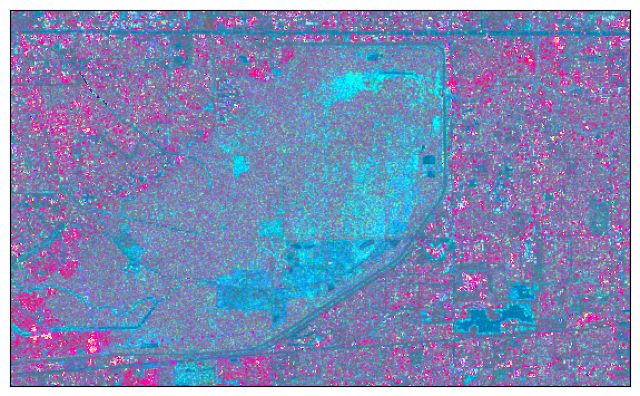

<Axes: >

In [ ]:
# Load image
image = rasterio.open(IMAGE_PATH)
bandNum = image.count
height = image.height
width = image.width
crs = image.crs
transform = image.transform
shape = (height, width)

image_vis = []
for x in [1, 2, 3, 4]:
  image_vis.append(image.read(x))
image_vis = np.stack(image_vis)

plot_size = (8, 8)
ep.plot_rgb(
  image_vis,
  figsize=plot_size,
  stretch=True,
)

In [ ]:
x = 4  # Set the value you want to iterate over
image_vis = []

image_vis.append(image.read(x))

image_vis = np.stack(image_vis)

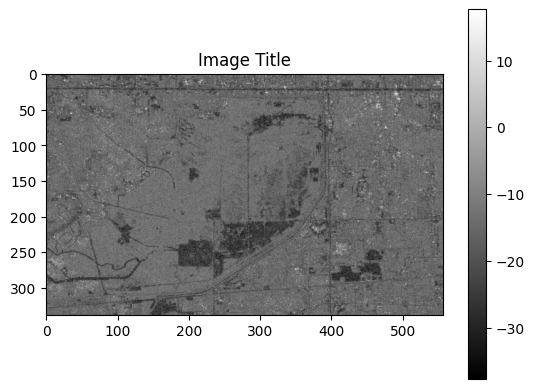

In [ ]:
import matplotlib.pyplot as plt

# Assuming image_vis is a NumPy array containing the image data
# If image_vis is a multi-dimensional array, you might want to select a specific image to plot (e.g., image_vis[0])

# Reshape the array to remove the singleton dimension
image_to_plot = image_vis[0] if len(image_vis.shape) == 3 else image_vis

plt.imshow(image_to_plot, cmap='gray')  # Assuming the image is grayscale; adjust cmap accordingly
plt.title('Image Title')
plt.colorbar()  # Add a colorbar if needed
plt.show()

In [ ]:
# Read sample
samples = pd.read_csv(SAMPLE_PATH)
samples = samples.sample(frac = 1) # Shuffle data
samples

,VV,VV_1,VH,VH_1,classvalue,sample
100,-15.584498,1.017295,0.968182,-21.618201,1,train
3732,-10.713874,0.942004,0.724337,-15.436765,2,test
2549,-15.034733,0.950480,1.121277,-26.908228,1,test
3427,-7.955508,0.954330,0.908223,-12.854453,2,test
2745,-13.309850,1.935238,1.315727,-18.248055,1,test
...,...,...,...,...,...,...
1927,-18.490868,1.384482,1.326914,-26.323446,1,test
319,-11.800510,1.142876,1.351174,-21.388535,1,train
1128,-15.252622,0.980220,1.026243,-22.373880,1,test
1078,-14.222035,1.392451,1.294732,-23.589127,1,test


In [ ]:
samples['VV/VH'] = samples['VV']/samples['VH']

In [ ]:
samples.shape

(3877, 7)

In [ ]:
# Split into train and test based on column
train = samples[samples['sample'] == 'train']
test = samples[samples['sample'] == 'test']

# Split between features and label
train_features = train[FEATURES]
train_label = train[LABEL]
test_features = test[FEATURES]
test_label = test[LABEL]

# Function to reshape array input
def reshape_input(array):
  shape = array.shape
  return array.reshape(shape[0], shape[1], 1)

# Convert samples dataframe (pandas) to numpy array
train_input = reshape_input(train_features.to_numpy())
test_input = reshape_input(test_features.to_numpy())

# Also make label data to categorical
train_output = to_categorical(train_label.to_numpy(), N_CLASSES + 1, int)
test_output = to_categorical(test_label.to_numpy(), N_CLASSES + 1, int)

# Show the data shape
print(f'Train features: {train_input.shape}\nTest features: {test_input.shape}\nTrain label: {train_output.shape}\nTest label: {test_output.shape}')

Train features: (727, 4, 1)
Test features: (3150, 4, 1)
Train label: (727, 3)
Test label: (3150, 3)


In [ ]:
test_label

,classvalue
3732,2
2549,1
3427,2
2745,1
2458,1
...,...
2051,1
2145,1
1927,1
1128,1


#CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Input

# Define input shape
input_shape = (4, 1)  # Shape matching your features

# Create a Sequential model
model = Sequential()

# Add a 1D convolutional layer
model.add(Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=input_shape))

# Flatten the output before the dense layers
model.add(Flatten())

# Add a fully connected dense layer
model.add(Dense(64, activation='relu'))

# Output layer with softmax activation for multi-class classification
num_classes = 3  # Number of classes in your dataset
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Assuming train_input, train_output, test_input, test_output are your data variables
# Train the model
history = model.fit(train_input, train_output, epochs=50, validation_data=(test_input, test_output))

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 3, 32)             96        
                                                                 
 flatten (Flatten)           (None, 96)                0         
                                                                 
 dense (Dense)               (None, 64)                6208      
                                                                 
 dense_1 (Dense)             (None, 3)                 195       
                                                                 
Total params: 6499 (25.39 KB)
Trainable params: 6499 (25.39 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/50
23/23 [==============================] - 2s 22ms/step - loss: 0.4893 - accuracy: 0.7304 - val_loss: 0.3884 - val_accuracy: 0.8337
Epoch 2/50
23

In [ ]:
# Train the model

# Compline the model
model.compile(
    optimizer='Adam',
    loss='CategoricalCrossentropy',
    metrics=['accuracy']
)

# Create callback to stop training if loss not decreasing
stop = EarlyStopping(
    monitor='loss',
    patience=5
)

# Fit the model
result = model.fit(
    x=train_input, y=train_output,
    validation_data=(test_input, test_output),
    batch_size=1024,
    callbacks=[stop],
    epochs=100,
)

Epoch 1/100
1/1 [==============================] - 1s 1s/step - loss: 0.0540 - accuracy: 0.9807 - val_loss: 0.9289 - val_accuracy: 0.7359
Epoch 2/100
1/1 [==============================] - 0s 53ms/step - loss: 0.0452 - accuracy: 0.9862 - val_loss: 1.0871 - val_accuracy: 0.7168
Epoch 3/100
1/1 [==============================] - 0s 58ms/step - loss: 0.0510 - accuracy: 0.9835 - val_loss: 1.0504 - val_accuracy: 0.7184
Epoch 4/100
1/1 [==============================] - 0s 62ms/step - loss: 0.0488 - accuracy: 0.9821 - val_loss: 0.9533 - val_accuracy: 0.7343
Epoch 5/100
1/1 [==============================] - 0s 63ms/step - loss: 0.0454 - accuracy: 0.9862 - val_loss: 0.8658 - val_accuracy: 0.7448
Epoch 6/100
1/1 [==============================] - 0s 60ms/step - loss: 0.0456 - accuracy: 0.9876 - val_loss: 0.8165 - val_accuracy: 0.7543
Epoch 7/100
1/1 [==============================] - 0s 61ms/step - loss: 0.0474 - accuracy: 0.9862 - val_loss: 0.8068 - val_accuracy: 0.7568


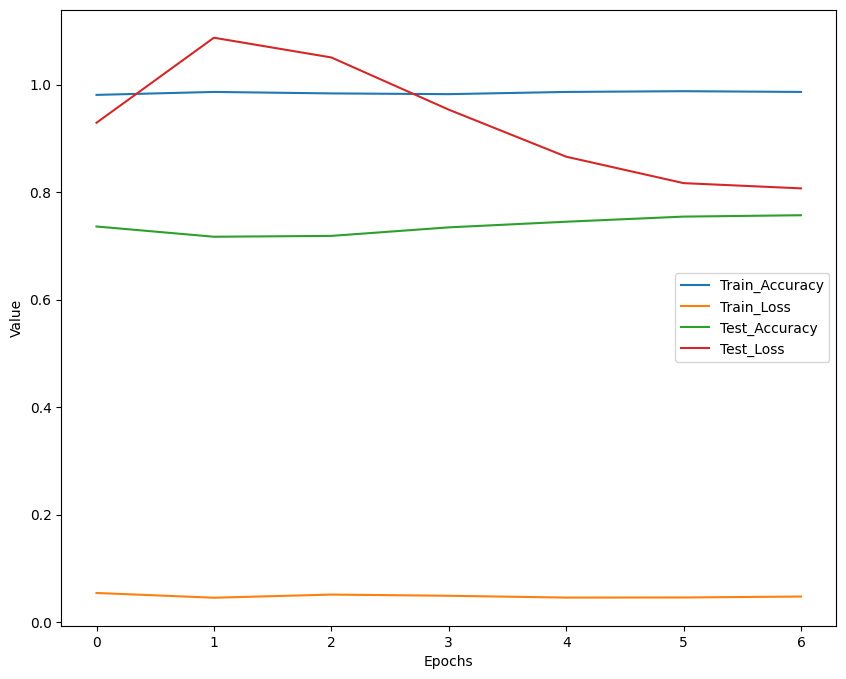

In [ ]:
# Show history
history = pd.DataFrame(result.history)

plt.figure(figsize = (10, 8))
plt.plot(range(len(history['accuracy'].values.tolist())), history['accuracy'].values.tolist(), label = 'Train_Accuracy')
plt.plot(range(len(history['loss'].values.tolist())), history['loss'].values.tolist(), label = 'Train_Loss')
plt.plot(range(len(history['val_accuracy'].values.tolist())), history['val_accuracy'].values.tolist(), label = 'Test_Accuracy')
plt.plot(range(len(history['val_loss'].values.tolist())), history['val_loss'].values.tolist(), label = 'Test_Loss')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.show()

99/99 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           1       0.93      0.76      0.84      2612
           2       0.39      0.72      0.50       538

    accuracy                           0.76      3150
   macro avg       0.66      0.74      0.67      3150
weighted avg       0.84      0.76      0.78      3150



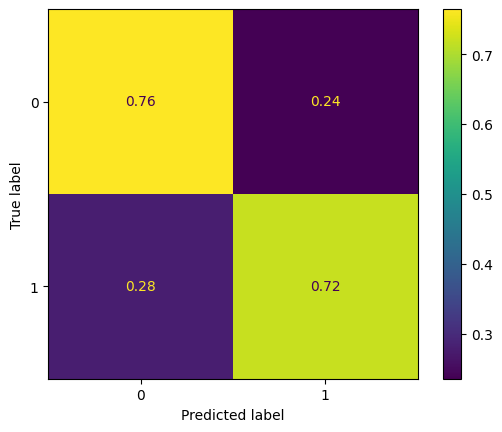

In [ ]:
# Predict test data
prediction = np.argmax(model.predict(test_input), 1).flatten()
label = np.argmax(test_output, 1).flatten()

# Confusion matrix
cm = confusion_matrix(label, prediction, normalize='true')
cm = ConfusionMatrixDisplay(cm)
cm.plot()

# Classification report
print(classification_report(label, prediction))

3/3 [==============================] - 0s 44ms/step


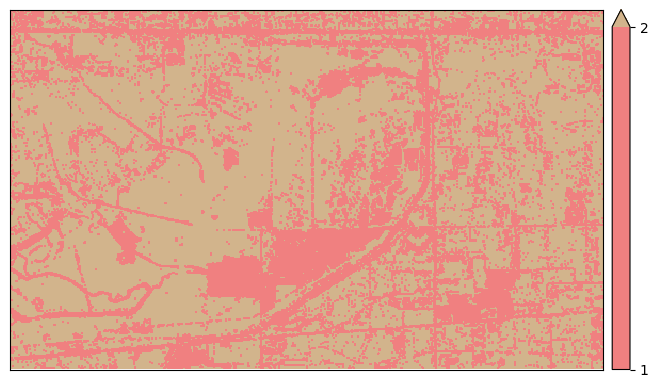

<Axes: >

In [ ]:
plot_size = (8, 8)

# Predict image using the model
image_input = []
for x in range(4):
    image_input.append(image.read(x + 1))

# Stack the image input along the last axis
image_input_stacked = np.stack(image_input, axis=-1)

# Reshape the stacked input to prepare for prediction
# Ensure that the shape aligns with what the model expects
image_input_reshaped = image_input_stacked.reshape(-1, 4, 1)  # Assuming input shape is (batch_size, 2, 1)

# Predict
prediction = model.predict(image_input_reshaped, batch_size=4096*20)
prediction = np.argmax(prediction, axis=1)
prediction = prediction.reshape(shape[0], shape[1])

# Visualize
cmap, norm = from_levels_and_colors(CLASSES, PALETTE, extend='max')
ep.plot_bands(prediction, cmap=cmap, norm=norm, figsize=plot_size)

Histogram

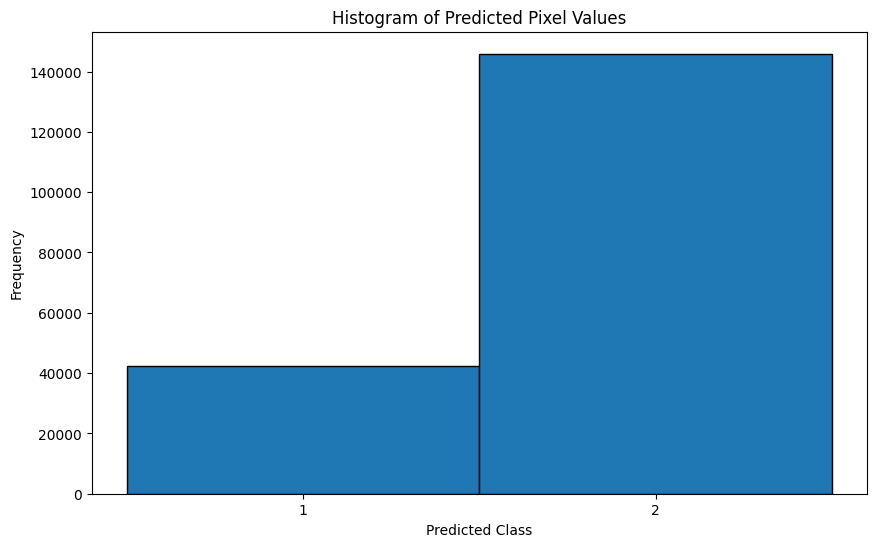

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'prediction' is a numpy array containing your predicted labels
plt.figure(figsize=(10, 6))
plt.hist(prediction.flatten(), bins=np.arange(prediction.min(), prediction.max() + 2) - 0.5, edgecolor='black')
plt.title('Histogram of Predicted Pixel Values')
plt.xlabel('Predicted Class')
plt.ylabel('Frequency')
plt.xticks(np.arange(prediction.min(), prediction.max() + 1))
plt.show()

Remove PSW bodies

In [ ]:
# Load the GSW dataset and select the 'seasonality' band
gsw = ee.Image("JRC/GSW1_2/GlobalSurfaceWater")
permanentWater = gsw.select('seasonality').gte(5)

# Clip the permanent water mask to your geometry
permanentWaterClipped = permanentWater.clip(extent)

# Mask out permanent water areas in your prediction
flooded_CD = prediction.where(permanentWaterClipped, 0)

# Visualization parameters
vis_params = {'min': 0, 'max': 1, 'palette': ['blue']}

# Create a folium map object
my_map = folium.Map(location=[20, 0], zoom_start=3)

# Add the permanent water layer to the map
my_map.add_ee_layer(permanentWaterClipped.selfMask(), vis_params, 'Permanent Water')

# Add the masked prediction layer to the map
my_map.add_ee_layer(flooded_CD.selfMask(), vis_params, 'Masked Prediction')

# Add a layer control panel to the map
my_map.add_child(folium.LayerControl())

# Display the map
my_map

AttributeError: 'numpy.ndarray' object has no attribute 'where'

Remove Slope

In [ ]:
# Save file to drive
save_location = '/content/drive/MyDrive/P3/'
name = 'P3_DL_Hou_CNN_floodmap.tif'
location = save_location + name

new_dataset = rasterio.open(
      location,
      mode='w', driver='GTiff',
      height = prediction.shape[0], width = prediction.shape[1],
      count=1, dtype=str(prediction.dtype),
      crs=crs,
      transform=transform
)
new_dataset.write(prediction, 1);
new_dataset.close()

In [ ]:
import rasterio
from rasterio.transform import from_origin
from rasterio.enums import Resampling

# Assuming 'prediction' contains the predicted labels
# Adjust these variables according to your specific data
output_file = 'predicted_result.tif'  # Path to save the predicted result
transform = transform

# Create a new raster file with the predicted values
with rasterio.open(output_file, 'w', driver='GTiff', height=shape[0], width=shape[1], count=1, dtype='uint8',
                   crs='EPSG:4326', transform=transform) as dst:
    dst.write(prediction.astype('uint8'), 1)  # Write the predicted values to the raster file as uint8


print(f"Predicted result saved to {output_file}")

Predicted result saved to predicted_result.tif


#XGBoost

In [ ]:
pip install xgboost

In [ ]:
import xgboost as xgb

In [ ]:
FEATURES = ['VV', 'VV_1', 'VH', 'VH_1']
#FEATURES = ['VV', 'VV_1', 'VH_1']
LABEL = ['classvalue']
SAMPLE_PATH = '/content/drive/MyDrive/P3/Samples_fl_Hou.csv'
# Assuming 'samples' DataFrame is loaded from the CSV file

# Split into train and test based on column
train = samples[samples['sample'] == 'train']
test = samples[samples['sample'] == 'test']

# Split between features and label
train_features = train[FEATURES]
train_label = train[LABEL]
test_features = test[FEATURES]
test_label = test[LABEL]

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Convert labels to 0-based indices
train_label_indices = train_label.squeeze().map({CLASSES[0]: 0, CLASSES[1]: 1})
test_label_indices = test_label.squeeze().map({CLASSES[0]: 0, CLASSES[1]: 1})

# Prepare train and test sets
X_train, X_test = train_features.to_numpy(), test_features.to_numpy()
y_train, y_test = train_label_indices.to_numpy(), test_label_indices.to_numpy()

# Create XGBoost Classifier
model = xgb.XGBClassifier(objective='binary:logistic')

# Train the model
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Classification report
print(classification_report(y_test, predictions))

Accuracy: 76.67%
              precision    recall  f1-score   support

           0       0.95      0.76      0.84      2612
           1       0.41      0.80      0.54       538

    accuracy                           0.77      3150
   macro avg       0.68      0.78      0.69      3150
weighted avg       0.86      0.77      0.79      3150



In [ ]:
print(predictions.shape)

(3150,)


In [ ]:
prediction

array([[1, 1, 1, ..., 1, 2, 1],
       [1, 2, 1, ..., 2, 1, 2],
       [1, 2, 2, ..., 2, 2, 1],
       ...,
       [2, 2, 1, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2]])

In [ ]:
import numpy as np

# Predict image using the model
image_input = []
for x in range(4):
    image_input.append(image.read(x + 1))

# Stack the image input along the last axis
image_input_stacked = np.stack(image_input, axis=-1)

# Reshape the stacked input to prepare for prediction
# Ensure that the shape aligns with what the model expects
image_input_reshaped = image_input_stacked.reshape(-1, 4)  # Assuming input shape is (samples, 4)

prediction = predictions.reshape(shape[0], shape[1])

# Visualize
# Note: Visualization part might need adjustment based on the plotting library used
cmap, norm = from_levels_and_colors(CLASSES, PALETTE, extend='max')
ep.plot_bands(prediction, cmap=cmap, norm=norm, figsize=plot_size)

ValueError: ignored

In [ ]:
# Load the image using rasterio
# (Make sure to replace 'your_image_file.tif' with the actual file path of your image)
image_path = '/content/drive/MyDrive/P3/DL_Sent-1_Houston.tif'
image = rasterio.open(image_path)

In [ ]:
# Read the image bands
bands = [1, 2, 3, 4]  # Adjust these indices based on your band order
image_input = [image.read(band) for band in bands]
image_input_stacked = np.stack(image_input, axis=-1)

# Reshape the stacked input to prepare for prediction
# Ensure that the shape aligns with what the model expects
image_input_reshaped = image_input_stacked.reshape(-1, len(bands))

# Define batch size
batch_size = 4096 * 20

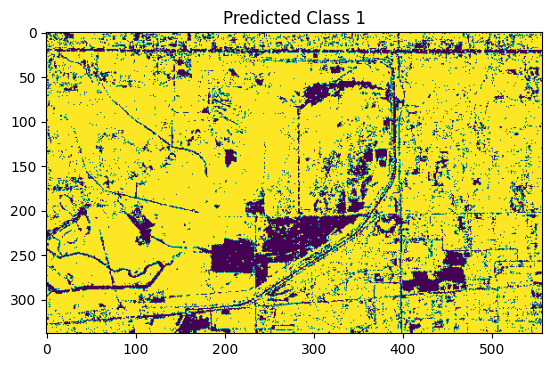

In [ ]:
# Predict in batches
prediction_batches = []
for i in range(0, image_input_reshaped.shape[0], batch_size):
    batch = image_input_reshaped[i:i + batch_size, :]
    predictions = model.predict(batch)
    prediction_batches.append(predictions)

# # Concatenate predictions from batches
# predictions = np.concatenate(prediction_batches)

# # Reshape predictions to the original image dimensions
# predictions_reshaped = predictions.reshape(image.height, image.width)

# # Visualize
# plt.imshow(predictions_reshaped, cmap='viridis')  # Use an appropriate colormap
# plt.title('Predicted Classes')
# plt.colorbar()
# plt.show()


# Predict using the XGBoost model
predictions = model.predict(image_input_reshaped)

# Reshape predictions to the original image dimensions
predictions_reshaped = predictions.reshape(image.height, image.width)

# Visualize only class 1 (assuming class 1 is represented by the value 1)
plt.imshow(predictions_reshaped == 1, cmap='viridis')  # Display pixels classified as class 1
plt.title('Predicted Class 1')
plt.show()


# # Specify colormap and normalization
# # (Replace 'your_colormap' with the desired colormap, e.g., 'viridis', 'cividis', 'jet', etc.)
# cmap, norm = from_levels_and_colors([0, 1], ['color_for_class_0', 'color_for_class_1'], extend='max')

# # Visualize using the specified colormap and normalization
# plt.imshow(predictions_reshaped, cmap=cmap, norm=norm)
# plt.title('Predicted Classes')
# plt.colorbar()
# plt.show()